In [1]:
import numpy as np
import glob
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [2]:
# Obtener una lista con la información de los archivos.npy

import os
from collections import defaultdict

def collect_npy_files(root_dir):
    """
    Recorre root_dir y subdirectorios buscando archivos .npy.
    Devuelve un dict que mapea el nombre de cada archivo (clave)
    a una lista de rutas completas donde aparece (valor).
    """
    npy_dict = defaultdict(list)

    # En un diccionario normal si preguntara por una clave que no existe se obtendría un
    # KeyErrpr, al hacer uso de defaultdict(list) en vez de un error recibo una lista vacia
    # para usar. Esto me permite que si ingreso con una clave nueva, su valor empieze como
    # una lista vacia automaticamente
    
    for dirpath, _, filenames in os.walk(root_dir):
        for name in filenames:
            if name.lower().endswith('.npy'):
                full_path = os.path.join(dirpath, name)
                npy_dict[name].append(full_path)

    # os.walk(root_dir) itera recursivamente sobre todos los directorios que se encuentren
    # en root_dir
    # - dirpath es la ruta al subdirectorio actual.
    # - (subdirectorios) lo ignoramos porque solo necesitamos archivos.
    # - filenames es la lista de nombres de archivos en dirpath.
    # luego se itera cada name en filenames y comprobamos que los archivos terminen en .npy
    
    return dict(npy_dict)

In [3]:
base_folder = r"..\\..\\..\\..\\Correos\\"   
npy_files = collect_npy_files(base_folder)

In [5]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# --- Paso 0: Supongamos que ya tienes npy_files dict ---
# npy_files = {
#   "2024-December-04_293-Camara_Amacayacu-1_crop0.npy": [ruta1, ruta2, ...],
#   "2024-December-04_294-Camara_Barranquilla-0_crop0.npy": [ruta3, ...],
#    ...
# }

# 1) Aplana el dict en dos listas
all_files = []
labels    = []
for fname, paths in npy_files.items():
    for path in paths:
        all_files.append(path)
        # aquí extraemos la etiqueta; por ejemplo, la parte entre guiones:
        # "2024-...-Camara_Amacayacu-1_crop0.npy" → "Camara_Amacayacu"
        etiqueta = fname.split("-")[2]  
        labels.append(etiqueta)


In [6]:
# 2) Carga todos los vectores
vectors = [np.load(f) for f in all_files]

# 3) Apila en matriz
X = np.vstack(vectors)

# 4) TSNE a 2D
X_2D = TSNE(n_components=2, perplexity=30).fit_transform(X)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


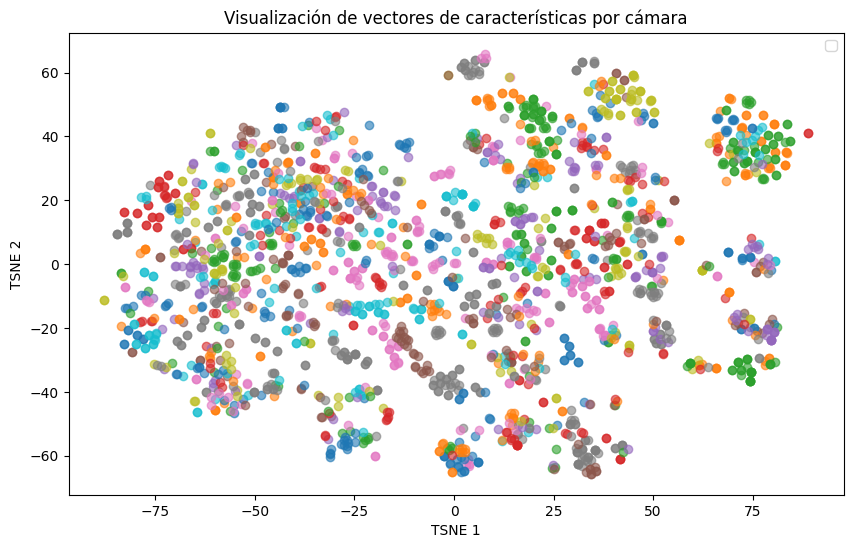

In [8]:
# 5) Graficar
plt.figure(figsize=(10, 6))
for label in set(labels):
    idxs = [i for i, l in enumerate(labels) if l == label]
    #plt.scatter(X_2D[idxs, 0], X_2D[idxs, 1], label=label, alpha=0.6)
    plt.scatter(X_2D[idxs, 0], X_2D[idxs, 1], alpha=0.6)

plt.legend()
plt.title("Visualización de vectores de características por cámara")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")
plt.show()

In [11]:
from sklearn.cluster import KMeans
from matplotlib.patches import Circle
import matplotlib.pyplot as plt

# Agrupar con KMeans
k = 10  # Número de grupos deseados
kmeans = KMeans(n_clusters=k, random_state=0).fit(X_2D)
labels_kmeans = kmeans.labels_
centroids = kmeans.cluster_centers_

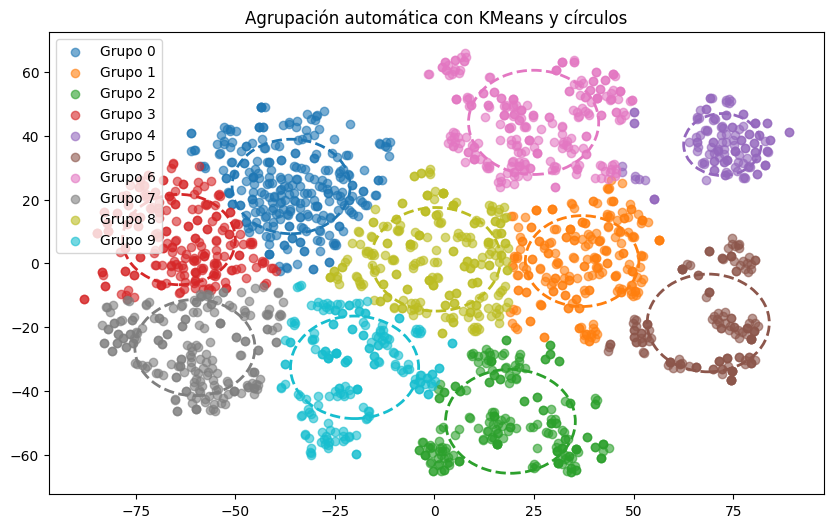

In [12]:
# Visualización
plt.figure(figsize=(10, 6))
cmap = plt.get_cmap('tab10')            # 'tab10' tiene 10 colores distintos
colors = [cmap(i) for i in range(k)]    # Una lista de 10 tuplas RGBA

for i in range(k):
    cluster_points = X_2D[labels_kmeans == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Grupo {i}', alpha=0.6, color=colors[i])
    
    # Dibujar círculo
    center = centroids[i]
    radius = np.linalg.norm(cluster_points - center, axis=1).mean()  # radio promedio
    circle = Circle(center, radius, edgecolor=colors[i], facecolor='none', lw=2, linestyle='--')
    plt.gca().add_patch(circle)

plt.title("Agrupación automática con KMeans y círculos")
plt.legend()
plt.show()

In [14]:
import pandas as pd

# Crear DataFrame con coordenadas
df = pd.DataFrame(X_2D, columns=['x', 'y'])

# Añadir nombre del archivo
df.insert(0, 'filename', all_files)  # insertamos en la primera columna

# Añadir etiquetas de cluster
df['cluster'] = labels_kmeans

print(df.head())

                                            filename          x          y  \
0  ..\\..\\..\\..\\Correos\\2024\December\04\TRAC...  12.861200 -31.322836   
1  ..\\..\\..\\..\\Correos\\2024\December\04\TRAC...  13.592845 -27.830853   
2  ..\\..\\..\\..\\Correos\\2024\December\04\TRAC... -37.460827 -31.447165   
3  ..\\..\\..\\..\\Correos\\2024\December\04\TRAC... -37.460907 -31.447176   
4  ..\\..\\..\\..\\Correos\\2024\December\04\TRAC...  63.812302 -32.130398   

   cluster  
0        2  
1        2  
2        9  
3        9  
4        5  


In [49]:
# Guardar el DataFrame como CSV
df.to_csv("coordenadas_clusters.csv", index=False)
print("✅ Archivo guardado como coordenadas_clusters.csv")

✅ Archivo guardado como coordenadas_clusters.csv


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import math

# Leer DataFrame (ya generado antes)
#df = pd.read_csv("X_2D_with_labels.csv")

# Iterar sobre clusters únicos
for cluster_id in df['cluster'].unique():
    cluster_df = df[df['cluster'] == cluster_id]
    
    # Limitar número de imágenes por collage (por ejemplo 25 máximo)
    subset = cluster_df.head(40)

    n_images = len(subset)
    cols = 10
    rows = math.ceil(n_images / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten()

    for ax in axes[n_images:]:
        ax.axis('off')  # apagar celdas vacías

    for i, (idx, row) in enumerate(subset.iterrows()):
        # Construir path a imagen original (reemplaza si es PNG u otra extensión)
        npy_file = os.path.normpath(row['filename'])
        img_path = npy_file.replace("features", "recortes").replace(".npy", ".jpg")
        # Para obtener el nombre de la imagen
        npy_file = os.path.basename(row['filename'])  # solo el nombre
        img_file = npy_file.replace(".npy", ".jpg")

        try:
            img = mpimg.imread(img_path)
            axes[i].imshow(img)
            axes[i].axis('off')
            axes[i].set_title(img_file, fontsize=6)
        except FileNotFoundError:
            axes[i].text(0.5, 0.5, "No image", ha='center', va='center')
            axes[i].axis('off')

    plt.suptitle(f"Cluster {cluster_id}", fontsize=14)
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.savefig(f"cluster_{cluster_id}_collage.png", dpi=300)
    plt.close()